# MSFT Next-Day Direction Predictor Model Development

**Author:** Lucan den Dekker  
**Project:** ADSAI Group 15 Block D Capstone  
**Date:** 2026-05-19  

---

This notebook trains and evaluates binary classification models to predict whether the next-day MSFT closing price will be higher (**UP = 1**) or lower (**DOWN = 0**) than the current day, using a ±0.5 % threshold to filter neutral days.

| Section | Content |
|---|---|
| 0 | Imports and Setup |
| 1 | Load Data |
| 2 | Feature Engineering |
| 3 | Train/Test Split & Scaling |
| 4 | Baseline Model |
| 5 | Logistic Regression |
| 6 | Random Forest |
| 7 | XGBoost |
| 8 | Model Comparison |
| 9 | Error Analysis |
| 10 | TimeSeriesSplit Validation |
| 11 | Business Value Interpretation |

## Required packages

Run the cell below once to install all dependencies before executing the rest of the notebook.

In [13]:
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib

Note: you may need to restart the kernel to use updated packages.


---
## Section 0 Imports and Setup

All dependencies are imported at the top of the notebook so that import errors fail fast. `RANDOM_SEED = 42` is applied to every stochastic component to guarantee full reproducibility. Python's `logging` module replaces ad-hoc `print` calls for pipeline milestones, giving timestamped, severity-levelled output that persists in the notebook's saved outputs.

**Key choices:**
- `RobustScaler` is used (not `StandardScaler`) because financial data contains extreme outliers (e.g. COVID-19 crash) that distort standard-deviation-based normalisation.
- `pathlib.Path` is used for all file paths so the notebook runs on both Windows and Unix without modification.

In [14]:
# Standard library
import os
import warnings
import logging
from pathlib import Path

# Scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Scikit-learn
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# XGBoost
from xgboost import XGBClassifier
import xgboost as xgb_lib

# Persistence
import joblib

# ── reproducibility ───────────────────────────────────────────────────────────
RANDOM_SEED: int = 42
np.random.seed(RANDOM_SEED)
warnings.filterwarnings('ignore')

# ── logging ───────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S',
)
logger = logging.getLogger('msft_modelling')

# ── plot style ────────────────────────────────────────────────────────────────
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    plt.style.use('seaborn-darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13


# ── project paths ─────────────────────────────────────────────────────────────
def find_project_root(marker: str = 'README.md') -> Path:
    """Walk up the directory tree until a marker file is found.

    Parameters
    ----------
    marker : str
        Filename expected at the repository root.

    Returns
    -------
    Path
        Absolute path to the repository root.
    """
    current = Path.cwd()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    logger.warning('Project root not found; falling back to cwd.')
    return current


PROJECT_ROOT = find_project_root()
DATA_PATH = (
    PROJECT_ROOT / 'msft-forecaster' / 'data' / 'processed' / 'msft_merged.csv'
)
MODELS_DIR = PROJECT_ROOT / 'models' / 'lucan'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

logger.info('Project root : %s', PROJECT_ROOT)
logger.info('Data path    : %s', DATA_PATH)
logger.info('Models dir   : %s', MODELS_DIR)

2026-05-20 16:42:54 | INFO | Project root : c:\Users\lucan\OneDrive - BUas\GitHub\2025-26d-fai1-adsai-group_15
2026-05-20 16:42:54 | INFO | Data path    : c:\Users\lucan\OneDrive - BUas\GitHub\2025-26d-fai1-adsai-group_15\msft-forecaster\data\processed\msft_merged.csv
2026-05-20 16:42:54 | INFO | Models dir   : c:\Users\lucan\OneDrive - BUas\GitHub\2025-26d-fai1-adsai-group_15\models\lucan


---
## Section 1 Load Data

The merged dataset `msft_merged.csv` was produced by the data-engineering pipeline and contains daily OHLCV data for MSFT joined with gold close, oil close, and VIX covering approximately 2015–2025. The date column is detected case-insensitively and set as the index.

Any missing values are logged as warnings and dropped so that subsequent rolling/lag operations produce deterministic results.

In [15]:
def load_data(path: Path) -> pd.DataFrame:
    """Load the MSFT merged CSV and return a date-indexed DataFrame.

    Parameters
    ----------
    path : Path
        Absolute path to the CSV file.

    Returns
    -------
    pd.DataFrame
        DataFrame sorted by date with a DatetimeIndex named 'Date'.

    Raises
    ------
    FileNotFoundError
        If the CSV file does not exist at the given path.
    ValueError
        If no date column can be detected.
    """
    if not path.exists():
        raise FileNotFoundError(f'Data file not found: {path}')

    df = pd.read_csv(path)

    # Detect the date column regardless of capitalisation
    date_col = next(
        (c for c in df.columns if c.lower() in ('date', 'datetime', 'timestamp')),
        None,
    )
    if date_col is None:
        raise ValueError(f'No date column found. Columns: {list(df.columns)}')

    df[date_col] = pd.to_datetime(df[date_col])
    df.set_index(date_col, inplace=True)
    df.index.name = 'Date'
    df.sort_index(inplace=True)
    return df


df_raw = load_data(DATA_PATH)
logger.info('Data loaded shape: %s', df_raw.shape)
logger.info(
    'Date range: %s to %s',
    df_raw.index.min().date(),
    df_raw.index.max().date(),
)

print(df_raw.head())
print()
df_raw.info()

# Missing-value audit
missing_counts = df_raw.isnull().sum()
total_missing = int(missing_counts.sum())
if total_missing > 0:
    logger.warning(
        '%d missing values found:\n%s',
        total_missing,
        missing_counts[missing_counts > 0],
    )
    df_raw = df_raw.dropna()
    logger.info('Rows with NaN dropped. New shape: %s', df_raw.shape)
else:
    logger.info('No missing values found.')

# Filter to 2019-01-01 onwards
CUTOFF_DATE = pd.Timestamp('2019-01-01')
rows_before = len(df_raw)
df_raw = df_raw.loc[df_raw.index >= CUTOFF_DATE]
rows_dropped = rows_before - len(df_raw)
logger.info(
    'Pre-2019 rows dropped: %d (kept %d). '
    'Pre-2019 data excluded to keep features relevant to the '
    'current market regime and reduce noise from older market conditions.',
    rows_dropped,
    len(df_raw),
)

2026-05-20 16:42:54 | INFO | Data loaded shape: (2818, 8)
2026-05-20 16:42:54 | INFO | Date range: 2015-02-17 to 2026-04-30
2026-05-20 16:42:54 | INFO | No missing values found.
2026-05-20 16:42:54 | INFO | Pre-2019 rows dropped: 976 (kept 1842). Pre-2019 data excluded to keep features relevant to the current market regime and reduce noise from older market conditions.


             Open     High    Low   Close      Volume   gold_close  oil_close  \
Date                                                                            
2015-02-17  43.97  44.0000  43.19  43.580  33695149.0  1208.099976  53.529999   
2015-02-18  43.63  43.7000  43.39  43.530  27111657.0  1199.699951  52.139999   
2015-02-19  43.18  43.5263  43.05  43.500  27556420.0  1207.099976  51.160000   
2015-02-20  43.51  43.8800  43.29  43.855  29721133.0  1204.400024  50.340000   
2015-02-23  43.70  44.1900  43.65  44.150  32518754.0  1200.300049  49.450001   

              vix  
Date               
2015-02-17  15.80  
2015-02-18  15.45  
2015-02-19  15.29  
2015-02-20  14.30  
2015-02-23  14.56  

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2818 entries, 2015-02-17 to 2026-04-30
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Open        2818 non-null   float64
 1   High        2818 non-null   float64
 2 

---
## Section 2 Feature Engineering

All features use data that would be available **at market close on day t** to predict the direction of day t+1's close.

| Feature | Description | Relevance |
|---|---|---|
| `lag_close_1` | Yesterday's close | Immediate price level context |
| `lag_close_2` | Two days ago close | Short-term trend anchor |
| `rolling_mean_5` | 5-day rolling mean of close | Short-term momentum |
| `rolling_mean_10` | 10-day rolling mean of close | Medium-term trend |
| `rolling_std_5` | 5-day rolling std of close | Recent volatility regime |
| `daily_return` | Today's % change in close | Intraday momentum signal |
| `price_range` | Today's high minus low | Intraday volatility |
| `lag_gold_return` | Yesterday's % change in gold | Safe-haven flow indicator |
| `lag_oil_return` | Yesterday's % change in oil | Macro risk-on/risk-off signal |
| `lag_vix_1` | Yesterday's VIX | Market fear / volatility index |

**Target definition:** A next-day return > +0.5 % is labelled **UP (1)**, a return < −0.5 % is labelled **DOWN (0)**. Days with a return between −0.5 % and +0.5 % are excluded as *neutral* predicting such marginal moves adds noise and reduces practical trading value.

In [16]:
def _detect_column(df: pd.DataFrame, candidates: list) -> str:
    """Return the first column name matching any candidate (case-insensitive).

    Parameters
    ----------
    df : pd.DataFrame
        Source dataframe.
    candidates : list of str
        Ordered list of expected column names (lowercase).

    Returns
    -------
    str
        The actual column name as it appears in df.

    Raises
    ------
    KeyError
        If none of the candidates match any column.
    """
    col_lower = {c.lower(): c for c in df.columns}
    for name in candidates:
        if name in col_lower:
            return col_lower[name]
    raise KeyError(f'None of {candidates} found in columns: {list(df.columns)}')


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add lag/rolling features, macro signals, and binary target to the dataframe.

    All features are constructed from data available at or before market close on
    day t; only the target uses day t+1 (via shift(-1)) and is excluded from X.

    Parameters
    ----------
    df : pd.DataFrame
        Raw merged MSFT dataframe with a DatetimeIndex.

    Returns
    -------
    pd.DataFrame
        DataFrame with engineered features and an integer 'target' column.
        Neutral days and rows with NaN are excluded.
    """
    df = df.copy()

    close = df[_detect_column(df, ['close', 'msft_close', 'adj close', 'adj_close'])]
    high  = df[_detect_column(df, ['high',  'msft_high'])]
    low   = df[_detect_column(df, ['low',   'msft_low'])]
    gold  = df[_detect_column(df, ['gold_close', 'gold close', 'gold', 'gc=f_close'])]
    oil   = df[_detect_column(df, ['oil_close', 'oil close', 'oil', 'cl=f_close', 'wti_close'])]
    vix   = df[_detect_column(df, ['vix', '^vix', 'vix_close'])]

    # MSFT price features (all use shift(1) so today's data is visible at prediction time)
    df['lag_close_1']     = close.shift(1)
    df['lag_close_2']     = close.shift(2)
    df['rolling_mean_5']  = close.rolling(5).mean()
    df['rolling_mean_10'] = close.rolling(10).mean()
    df['rolling_std_5']   = close.rolling(5).std()
    df['daily_return']    = close.pct_change() * 100
    df['price_range']     = high - low

    # Macro lag features (previous day's values)
    df['lag_gold_return'] = gold.pct_change().shift(1) * 100
    df['lag_oil_return']  = oil.pct_change().shift(1) * 100
    df['lag_vix_1']       = vix.shift(1)

    # Binary target: next-day return direction with neutral zone exclusion
    next_day_return = (close.shift(-1) - close) / close * 100
    df['target'] = np.select(
        [next_day_return > 0.5, next_day_return < -0.5],
        [1, 0],
        default=np.nan,  # neutral days excluded
    )

    df = df.dropna(subset=['target'])
    df['target'] = df['target'].astype(int)
    df = df.dropna()

    class_counts = df['target'].value_counts().sort_index()
    logger.info(
        'Target class balance DOWN(0): %d | UP(1): %d',
        class_counts.get(0, 0),
        class_counts.get(1, 0),
    )
    logger.info('Final dataset shape after feature engineering: %s', df.shape)
    return df


df = engineer_features(df_raw)
print(df[['lag_close_1', 'rolling_mean_5', 'daily_return', 'lag_vix_1', 'target']].head(10))

2026-05-20 16:42:54 | INFO | Target class balance DOWN(0): 581 | UP(1): 701
2026-05-20 16:42:54 | INFO | Final dataset shape after feature engineering: (1282, 19)


            lag_close_1  rolling_mean_5  daily_return  lag_vix_1  target
Date                                                                    
2019-01-16       105.01         103.768      0.352347      18.60       1
2019-01-17       105.38         104.272      0.702221      19.04       1
2019-01-18       106.12         105.254      1.498304      18.06       0
2019-01-22       107.71         105.980     -1.884690      17.80       1
2019-01-24       106.71         106.484     -0.477931      19.52       1
2019-01-25       106.20         106.694      0.913371      18.89       0
2019-01-28       107.17         106.168     -1.950173      17.42       0
2019-01-29       105.08         105.620     -2.036544      18.87       1
2019-01-30       102.94         105.554      3.341752      19.13       0
2019-01-31       106.38         105.200     -1.833051      17.66       0


---
## Section 3 Train/Test Split & Feature Scaling

### Why no shuffling?
Financial time series have temporal dependencies: future values are influenced by past values. If we shuffle and split randomly, rows from 2024 end up in the training set and rows from 2016 end up in the test set. The model would implicitly learn from the future **lookahead bias** producing inflated metrics that collapse in production.

Instead we use a **time-based split**: the first 80 % of rows (chronologically) form the training set and the remaining 20 % form the test set. No data from the future is ever visible during training.

### Why RobustScaler?
`StandardScaler` subtracts the mean and divides by the standard deviation. A single extreme event (e.g. the −35 % COVID crash in March 2020) inflates the standard deviation and compresses all other values toward zero, destroying signal. `RobustScaler` uses the **median and interquartile range**, which are resistant to outliers a much better fit for financial data.

> **Important:** The scaler is fitted **only on the training set** and then applied to the test set. Fitting on the full dataset would leak test-period statistics into training normalisation.

In [17]:
FEATURE_COLUMNS = [
    'lag_close_1',
    'lag_close_2',
    'rolling_mean_5',
    'rolling_mean_10',
    'rolling_std_5',
    'daily_return',
    'price_range',
    'lag_gold_return',
    'lag_oil_return',
    'lag_vix_1',
]

# ── time-based 80/20 split ────────────────────────────────────────────────────
split_idx = int(len(df) * 0.80)
df_train  = df.iloc[:split_idx]
df_test   = df.iloc[split_idx:]

logger.info(
    'Train: %d rows | %s to %s',
    len(df_train), df_train.index.min().date(), df_train.index.max().date(),
)
logger.info(
    'Test : %d rows | %s to %s',
    len(df_test), df_test.index.min().date(), df_test.index.max().date(),
)

X_train = df_train[FEATURE_COLUMNS]
X_test  = df_test[FEATURE_COLUMNS]
y_train = df_train['target']
y_test  = df_test['target']

# ── RobustScaler: fit on train only ──────────────────────────────────────────
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)   # learn median/IQR from train
X_test_scaled  = scaler.transform(X_test)         # apply same transform to test

# ── persist scaler ─────────────────────────────────────────────────────────────
scaler_path = MODELS_DIR / 'scaler_lucan_it1.pkl'
joblib.dump(scaler, scaler_path)
logger.info('Scaler saved to %s', scaler_path)

print(f'X_train shape: {X_train.shape}  |  y_train balance: {y_train.value_counts().to_dict()}')
print(f'X_test  shape: {X_test.shape}   |  y_test  balance: {y_test.value_counts().to_dict()}')

2026-05-20 16:42:54 | INFO | Train: 1025 rows | 2019-01-16 to 2024-09-27
2026-05-20 16:42:54 | INFO | Test : 257 rows | 2024-09-30 to 2026-04-29
2026-05-20 16:42:54 | INFO | Scaler saved to c:\Users\lucan\OneDrive - BUas\GitHub\2025-26d-fai1-adsai-group_15\models\lucan\scaler_lucan_it1.pkl


X_train shape: (1025, 10)  |  y_train balance: {1: 569, 0: 456}
X_test  shape: (257, 10)   |  y_test  balance: {1: 132, 0: 125}


---
## Section 4 Baseline Model (Majority-Class Classifier)

Before training any real model, a naive baseline establishes the **performance floor**. The majority-class baseline predicts the most frequent class for every sample. For a roughly balanced binary problem, this yields ~50 % accuracy. Any model that cannot beat this baseline provides no predictive value.

Because we filtered neutral days, the class distribution will not be perfectly 50/50, but the baseline gives a meaningful lower bound to compare against. If the UP class is slightly more frequent (markets trend upward long-term), the baseline simply always predicts UP, achieving its accuracy without any learned signal.

In [18]:
def evaluate_model(y_true, y_pred, model_name: str) -> dict:
    """Compute weighted classification metrics and return as a results dict.

    Parameters
    ----------
    y_true : array-like
        Ground-truth labels.
    y_pred : array-like
        Predicted labels from the model.
    model_name : str
        Human-readable identifier used in logging and the results table.

    Returns
    -------
    dict
        Keys: 'Model', 'Accuracy', 'Precision', 'Recall', 'F1'.
    """
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    logger.info(
        '%s Acc: %.4f | Prec: %.4f | Rec: %.4f | F1: %.4f',
        model_name, acc, prec, rec, f1,
    )
    return {
        'Model': model_name,
        'Accuracy':  round(acc,  4),
        'Precision': round(prec, 4),
        'Recall':    round(rec,  4),
        'F1':        round(f1,   4),
    }


def plot_confusion_matrix(y_true, y_pred, model_name: str) -> None:
    """Plot a seaborn heatmap confusion matrix.

    Parameters
    ----------
    y_true : array-like
        Ground-truth labels.
    y_pred : array-like
        Predicted labels.
    model_name : str
        Used as the plot title.
    """
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['DOWN (0)', 'UP (1)'],
        yticklabels=['DOWN (0)', 'UP (1)'],
        ax=ax,
    )
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    ax.set_title(f'Confusion Matrix {model_name}')
    plt.tight_layout()
    plt.show()


# ── majority-class baseline ────────────────────────────────────────────────────
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_SEED)
dummy.fit(X_train_scaled, y_train)
y_pred_dummy = dummy.predict(X_test_scaled)

baseline_metrics = evaluate_model(y_test, y_pred_dummy, 'Baseline (Majority Class)')
print(classification_report(y_test, y_pred_dummy, target_names=['DOWN', 'UP']))

2026-05-20 16:42:54 | INFO | Baseline (Majority Class) Acc: 0.5136 | Prec: 0.2638 | Rec: 0.5136 | F1: 0.3486


              precision    recall  f1-score   support

        DOWN       0.00      0.00      0.00       125
          UP       0.51      1.00      0.68       132

    accuracy                           0.51       257
   macro avg       0.26      0.50      0.34       257
weighted avg       0.26      0.51      0.35       257



---
## Section 5 Iteration 1: Logistic Regression

Logistic Regression is the natural first step beyond the baseline for binary classification. It is:
- **Interpretable**: the sign and magnitude of coefficients reveal which features push predictions toward UP or DOWN.
- **Fast**: trains in seconds, making it a rapid sanity check before heavier models.
- **Linear**: assumes a linear decision boundary in feature space, which may underfit complex market dynamics.

`max_iter=1000` ensures convergence on the scaled features. If precision and recall diverge significantly between classes, this signals class imbalance or a bias in the feature set.

2026-05-20 16:42:54 | INFO | Logistic Regression Acc: 0.5136 | Prec: 0.5133 | Rec: 0.5136 | F1: 0.5134


              precision    recall  f1-score   support

        DOWN       0.50      0.49      0.49       125
          UP       0.53      0.54      0.53       132

    accuracy                           0.51       257
   macro avg       0.51      0.51      0.51       257
weighted avg       0.51      0.51      0.51       257



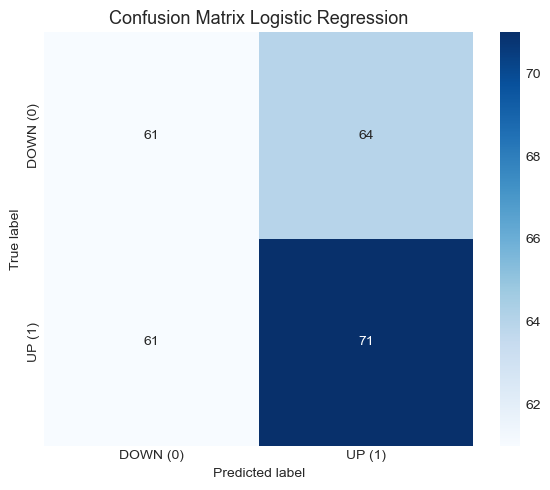

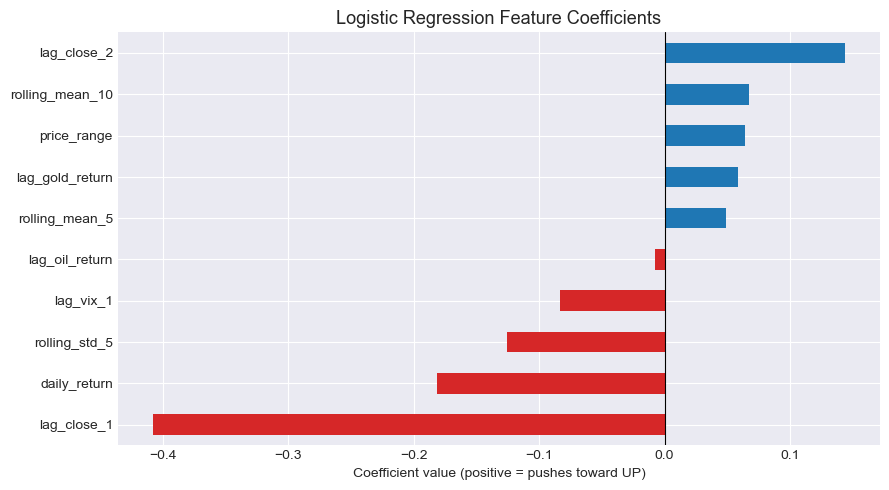

2026-05-20 16:42:55 | INFO | Logistic Regression saved to c:\Users\lucan\OneDrive - BUas\GitHub\2025-26d-fai1-adsai-group_15\models\lucan\logistic_regression_lucan_it1.pkl


In [19]:
lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
lr_metrics = evaluate_model(y_test, y_pred_lr, 'Logistic Regression')

print(classification_report(y_test, y_pred_lr, target_names=['DOWN', 'UP']))
plot_confusion_matrix(y_test, y_pred_lr, 'Logistic Regression')

# Coefficient inspection shows which features drive each direction
coef_df = (
    pd.Series(lr_model.coef_[0], index=FEATURE_COLUMNS)
    .sort_values()
)
fig, ax = plt.subplots(figsize=(9, 5))
coef_df.plot(kind='barh', ax=ax, color=['#d62728' if v < 0 else '#1f77b4' for v in coef_df])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Feature Coefficients')
ax.set_xlabel('Coefficient value (positive = pushes toward UP)')
plt.tight_layout()
plt.show()

# ── persist ────────────────────────────────────────────────────────────────────
lr_path = MODELS_DIR / 'logistic_regression_lucan_it1.pkl'
joblib.dump(lr_model, lr_path)
logger.info('Logistic Regression saved to %s', lr_path)

### Interpretation

Logistic Regression provides a linear decision boundary. In practice, stock price movements are driven by non-linear interactions (e.g. high VIX AND falling gold → flight to safety), which a linear model cannot capture.

- If F1 beats the baseline: the linear features carry real directional signal.
- If precision ≫ recall for one class: the model is biased toward the majority class. This is common without class weighting.
- Features with the largest positive coefficients are the strongest UP predictors; negative coefficients indicate DOWN drivers.

This model serves as the **interpretable baseline** against which tree-based and gradient boosting models will be compared.

---
## Section 6 Iteration 2: Random Forest

Random Forest is an ensemble of decision trees, each trained on a bootstrapped sample of the training data with random feature subsets. Key advantages over Logistic Regression:

- **Non-linear**: captures feature interactions (e.g. high volatility + high VIX lagged effects).
- **Robust to scale**: tree splits are threshold-based, so the RobustScaler is less critical here (but kept for consistency).
- **Feature importance**: Mean Decrease in Impurity (MDI) gives an interpretable ranking of which features carry the most predictive signal.

`n_estimators=100` provides a good bias-variance trade-off. With `random_state=42`, the forest is fully reproducible.

2026-05-20 16:42:55 | INFO | Random Forest Acc: 0.4514 | Prec: 0.4519 | Rec: 0.4514 | F1: 0.4431


              precision    recall  f1-score   support

        DOWN       0.45      0.58      0.51       125
          UP       0.45      0.33      0.38       132

    accuracy                           0.45       257
   macro avg       0.45      0.45      0.44       257
weighted avg       0.45      0.45      0.44       257



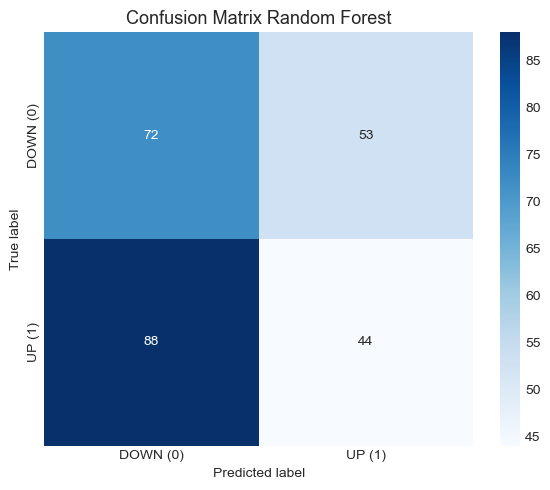

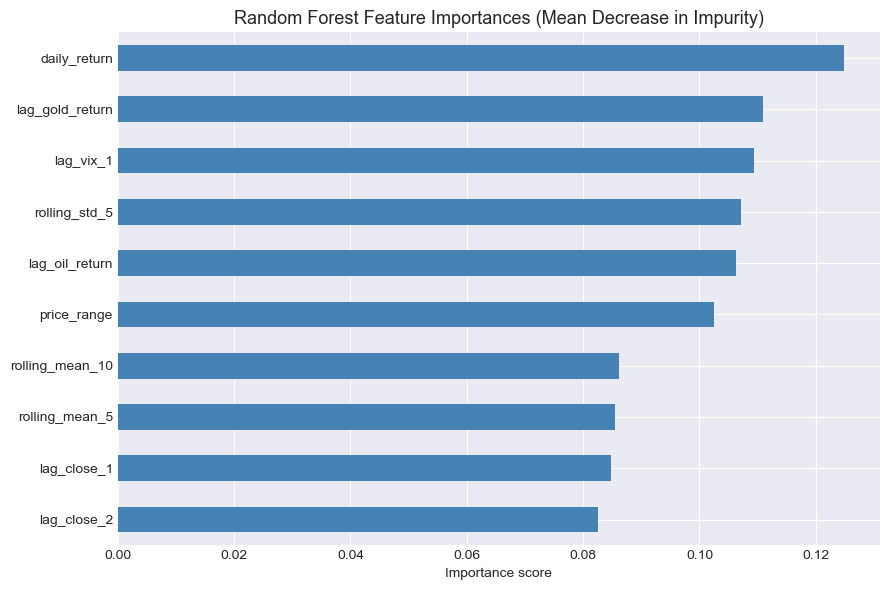

2026-05-20 16:42:55 | INFO | Random Forest saved to c:\Users\lucan\OneDrive - BUas\GitHub\2025-26d-fai1-adsai-group_15\models\lucan\random_forest_lucan_it1.pkl


In [20]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
rf_metrics = evaluate_model(y_test, y_pred_rf, 'Random Forest')

print(classification_report(y_test, y_pred_rf, target_names=['DOWN', 'UP']))
plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest')

# ── feature importances ───────────────────────────────────────────────────────
importance_series = (
    pd.Series(rf_model.feature_importances_, index=FEATURE_COLUMNS)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 6))
importance_series.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Random Forest Feature Importances (Mean Decrease in Impurity)')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.show()

# ── persist ────────────────────────────────────────────────────────────────────
rf_path = MODELS_DIR / 'random_forest_lucan_it1.pkl'
joblib.dump(rf_model, rf_path)
logger.info('Random Forest saved to %s', rf_path)

### Interpretation

The feature importance chart shows which signals the forest relied on most. We would intuitively expect **price-based features** (`rolling_mean_5`, `rolling_mean_10`, `lag_close_1`) to rank highly because they directly encode recent momentum. **Macro features** (`lag_vix_1`, `lag_gold_return`) contribute as secondary signals particularly during risk-off regimes.

If `daily_return` (today's intraday move) ranks highly, the model is capturing **mean-reversion or momentum continuation** patterns both documented phenomena in equity markets.

Random Forest's non-linearity and ensemble averaging typically outperform Logistic Regression on financial classification tasks where feature interactions matter more than linear relationships.

---
## Section 7 Iteration 3: XGBoost

XGBoost (Extreme Gradient Boosting) builds trees **sequentially**, each correcting the residual errors of its predecessor. Compared to Random Forest:

- **Higher accuracy** in practice on tabular data (confirmed across many Kaggle competitions and financial ML research).
- **Regularisation built-in**: `max_depth=4` and `learning_rate=0.05` reduce overfitting on the relatively small MSFT dataset.
- **More hyperparameters**: this also means it requires more careful tuning to avoid overfitting.

`eval_metric='logloss'` logs training loss during fitting. `learning_rate=0.05` (shrinkage) forces the model to learn slowly, adding robustness.

2026-05-20 16:42:55 | INFO | XGBoost Acc: 0.4436 | Prec: 0.4446 | Rec: 0.4436 | F1: 0.4417


              precision    recall  f1-score   support

        DOWN       0.44      0.50      0.47       125
          UP       0.45      0.39      0.42       132

    accuracy                           0.44       257
   macro avg       0.44      0.45      0.44       257
weighted avg       0.44      0.44      0.44       257



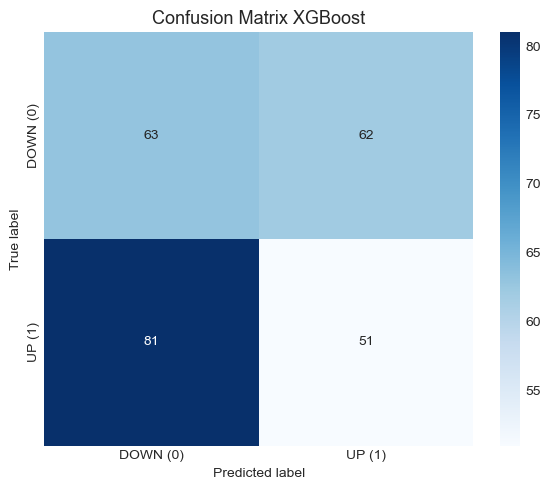

2026-05-20 16:42:56 | INFO | XGBoost saved to c:\Users\lucan\OneDrive - BUas\GitHub\2025-26d-fai1-adsai-group_15\models\lucan\xgboost_lucan_it1.pkl


In [21]:
# use_label_encoder was removed in XGBoost 2.0 include only for older versions
_xgb_major = int(xgb_lib.__version__.split('.')[0])
_xgb_params: dict = dict(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    eval_metric='logloss',
    random_state=RANDOM_SEED,
)
if _xgb_major < 2:
    _xgb_params['use_label_encoder'] = False

xgb_model = XGBClassifier(**_xgb_params)
xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_model.predict(X_test_scaled)
xgb_metrics = evaluate_model(y_test, y_pred_xgb, 'XGBoost')

print(classification_report(y_test, y_pred_xgb, target_names=['DOWN', 'UP']))
plot_confusion_matrix(y_test, y_pred_xgb, 'XGBoost')

# ── persist ────────────────────────────────────────────────────────────────────
xgb_path = MODELS_DIR / 'xgboost_lucan_it1.pkl'
joblib.dump(xgb_model, xgb_path)
logger.info('XGBoost saved to %s', xgb_path)

### XGBoost vs Random Forest

| Dimension | Random Forest | XGBoost |
|---|---|---|
| Learning strategy | Parallel (bagging) | Sequential (boosting) |
| Overfitting risk | Low (averaging) | Medium (must tune `learning_rate`, `max_depth`) |
| Training speed | Fast | Slower per estimator, but fewer needed |
| Typical accuracy on tabular data | Good | Often better |
| Interpretability | Feature importance | Feature importance + SHAP |

On a ~2,000-row financial dataset, XGBoost's boosting strategy may overfit if `learning_rate` is too high or `max_depth` is too large. The conservative `lr=0.05, depth=4` settings mitigate this.

---
## Section 8 Model Comparison

All four models are compared across four metrics. **F1 (weighted) is the primary metric** because:

1. It balances precision and recall both types of error (false positives and false negatives) carry real financial consequences.
2. Weighted averaging accounts for any remaining class imbalance.
3. Accuracy alone is misleading if one class is more frequent a model can achieve high accuracy by always predicting the majority class.

For a trading signal, a **false positive** (predicted UP, actually DOWN) means buying into a losing day; a **false negative** (predicted DOWN, actually UP) means missing a profitable day. Neither is free, so we need a metric that penalises both.

                    Model  Accuracy  Precision  Recall     F1
Baseline (Majority Class)    0.5136     0.2638  0.5136 0.3486
      Logistic Regression    0.5136     0.5133  0.5136 0.5134
            Random Forest    0.4514     0.4519  0.4514 0.4431
                  XGBoost    0.4436     0.4446  0.4436 0.4417


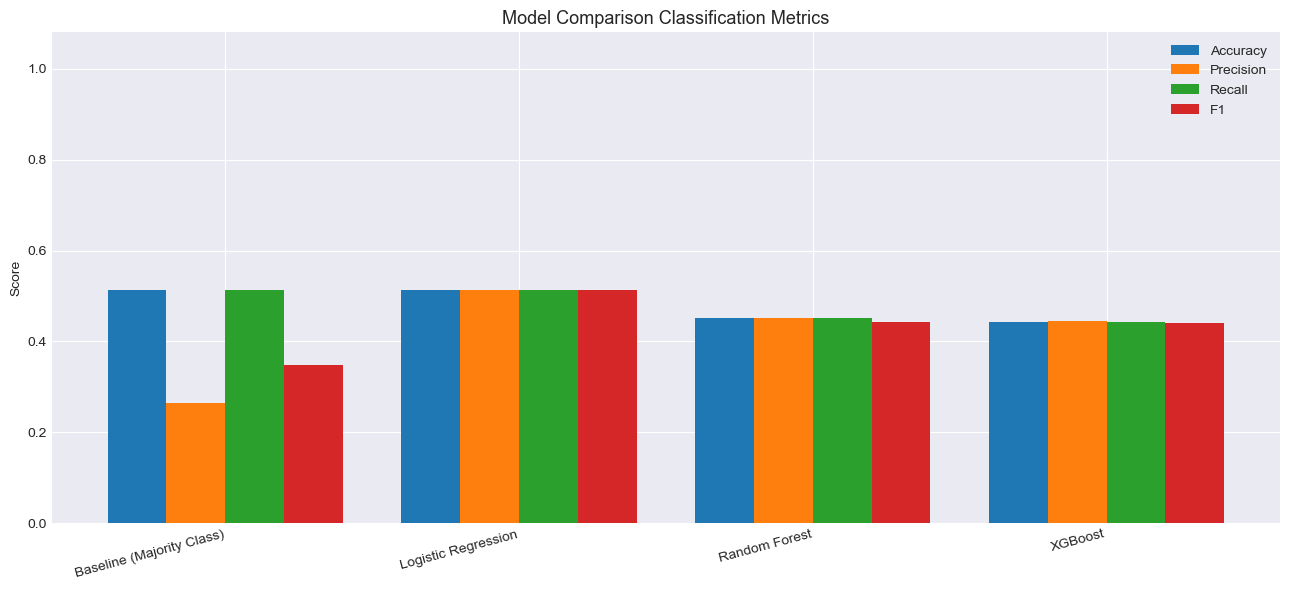

2026-05-20 16:42:56 | INFO | Best model by F1: Logistic Regression (F1 = 0.5134)



Best model: Logistic Regression   F1 = 0.5134


In [22]:
results_df = pd.DataFrame([
    baseline_metrics,
    lr_metrics,
    rf_metrics,
    xgb_metrics,
])
print(results_df.to_string(index=False))

# ── grouped bar chart ─────────────────────────────────────────────────────────
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1']
x     = np.arange(len(results_df))
width = 0.20

fig, ax = plt.subplots(figsize=(13, 6))
for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i * width, results_df[metric], width, label=metric)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score')
ax.set_title('Model Comparison Classification Metrics')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

# ── select best model by F1 ────────────────────────────────────────────────────
best_row = results_df.loc[results_df['F1'].idxmax()]
BEST_MODEL_NAME: str = best_row['Model']
logger.info('Best model by F1: %s (F1 = %.4f)', BEST_MODEL_NAME, best_row['F1'])
print(f'\nBest model: {BEST_MODEL_NAME}   F1 = {best_row["F1"]:.4f}')

---
## Section 9 Error Analysis

Summary metrics obscure *where* and *when* a model fails. This section goes deeper:

1. **Confusion matrix with percentages** distinguishes absolute error counts from relative rates.
2. **Temporal error map** overlays false positives (▼) and false negatives (▲) on the MSFT price chart, revealing whether errors cluster around specific market regimes (earnings, high-volatility periods, structural breaks).

**Error consequences for an investor:**
- *False positive (pred UP, actual DOWN)*: investor buys, market falls → direct financial loss.
- *False negative (pred DOWN, actual UP)*: investor stays out, market rises → opportunity cost.

Both are costly; neither is obviously worse. The F1 metric correctly penalises both.

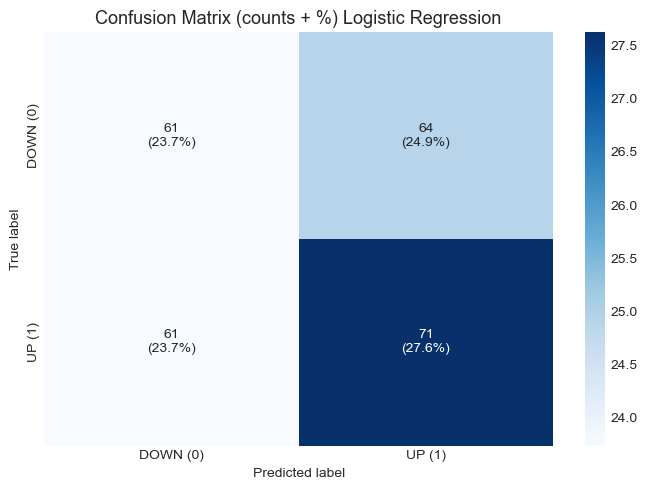

2026-05-20 16:42:56 | INFO | False positives (predicted UP, actual DOWN): 64
2026-05-20 16:42:56 | INFO | False negatives (predicted DOWN, actual UP): 61


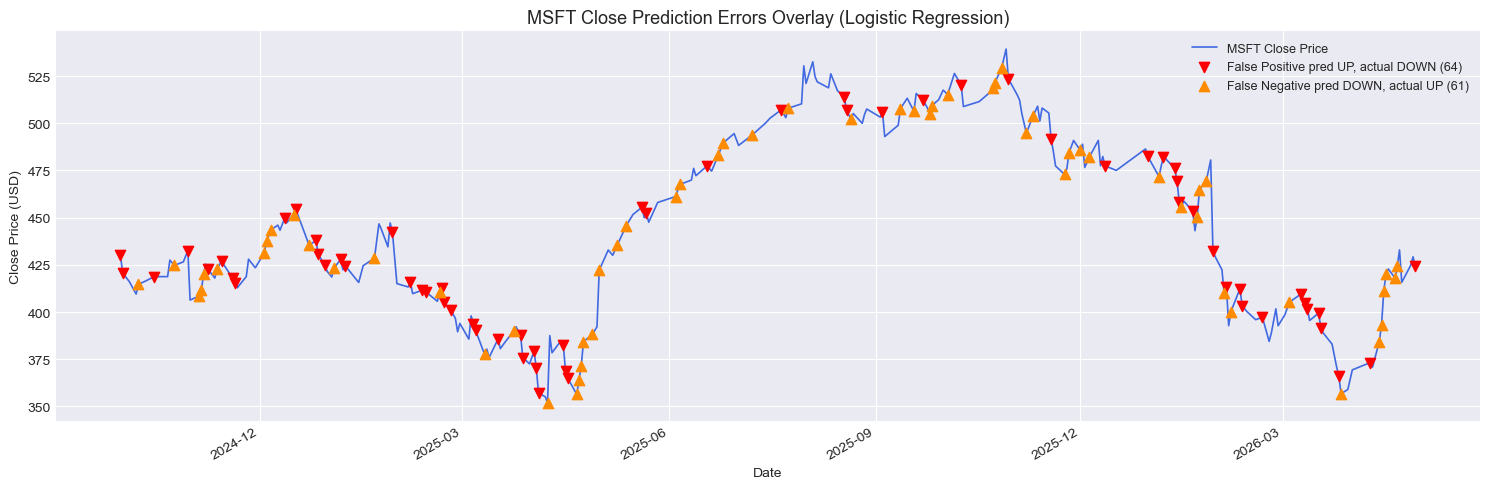

In [23]:
# Map best model name to its prediction array
_model_preds = {
    'Baseline (Majority Class)': y_pred_dummy,
    'Logistic Regression':       y_pred_lr,
    'Random Forest':             y_pred_rf,
    'XGBoost':                   y_pred_xgb,
}
y_pred_best = _model_preds[BEST_MODEL_NAME]

# ── confusion matrix with counts and percentages ──────────────────────────────
cm      = confusion_matrix(y_test, y_pred_best)
cm_pct  = cm.astype(float) / cm.sum() * 100
annot   = np.array([
    [f'{cm[i, j]}\n({cm_pct[i, j]:.1f}%)' for j in range(cm.shape[1])]
    for i in range(cm.shape[0])
])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm_pct,
    annot=annot,
    fmt='',
    cmap='Blues',
    xticklabels=['DOWN (0)', 'UP (1)'],
    yticklabels=['DOWN (0)', 'UP (1)'],
    ax=ax,
)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title(f'Confusion Matrix (counts + %) {BEST_MODEL_NAME}')
plt.tight_layout()
plt.show()

# ── locate false positives and false negatives in the test set ────────────────
y_pred_series = pd.Series(y_pred_best, index=df_test.index, name='pred')

false_pos = df_test.index[(y_pred_series == 1) & (y_test == 0)]   # pred UP, actual DOWN
false_neg = df_test.index[(y_pred_series == 0) & (y_test == 1)]   # pred DOWN, actual UP

logger.info('False positives (predicted UP, actual DOWN): %d', len(false_pos))
logger.info('False negatives (predicted DOWN, actual UP): %d', len(false_neg))

# ── error overlay on MSFT close price ────────────────────────────────────────
close_col = _detect_column(df, ['close', 'msft_close', 'adj close', 'adj_close'])

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(
    df_test.index,
    df_test[close_col],
    color='royalblue', linewidth=1.2, label='MSFT Close Price',
)
ax.scatter(
    false_pos,
    df_test.loc[false_pos, close_col],
    color='red', marker='v', s=55, zorder=5,
    label=f'False Positive pred UP, actual DOWN ({len(false_pos)})',
)
ax.scatter(
    false_neg,
    df_test.loc[false_neg, close_col],
    color='darkorange', marker='^', s=55, zorder=5,
    label=f'False Negative pred DOWN, actual UP ({len(false_neg)})',
)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
fig.autofmt_xdate(rotation=30)
ax.set_xlabel('Date')
ax.set_ylabel('Close Price (USD)')
ax.set_title(f'MSFT Close Prediction Errors Overlay ({BEST_MODEL_NAME})')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Error Analysis Interpretation

Errors that appear **clustered** around specific periods rather than uniformly distributed across the test window suggest the model struggles with **regime changes** periods where the underlying data-generating process shifts. Common culprits:

- **High-volatility periods** (large VIX spikes, earnings announcements, macro shocks): the model was trained on a feature distribution that underrepresents extreme volatility.
- **Sustained trends**: a model that relies heavily on lagged features may lag behind a strong directional trend before adapting.
- **Structural breaks**: the COVID-19 crash (March 2020) and Federal Reserve rate-hike cycles (2022) represent distribution shifts the training data may not fully represent in the test window.

**Practical investor consequences:**
- A cluster of false positives on a declining market segment means the model would have generated multiple losing trades in sequence potentially catastrophic for a leveraged strategy.
- Isolated, uniformly distributed errors are more manageable with a simple stop-loss rule.

---
## Section 10 TimeSeriesSplit Cross-Validation

A single train/test split produces one estimate of model performance it may be optimistic or pessimistic depending on whether the test period happened to be easier or harder than average. **Cross-validation** gives multiple independent estimates and quantifies uncertainty.

### Why TimeSeriesSplit and not StratifiedKFold?

`StratifiedKFold` shuffles the data before splitting into folds. For time-series data this creates **lookahead bias**: fold 1's test set might contain 2019 data while its training set contains 2021 data, allowing the model to implicitly learn from the future. Reported metrics under StratifiedKFold would be wildly optimistic and entirely unrepresentative of live performance.

`TimeSeriesSplit` preserves chronological order: each fold's training set ends **before** its test set begins. The five folds expand progressively, simulating how a model trained at different historical cut-offs would generalise to the subsequent period. The mean and standard deviation of F1 across folds give a reliable estimate of expected production performance and its uncertainty.

2026-05-20 16:42:56 | INFO | TimeSeriesSplit CV mean F1: 0.4691 | std: 0.0633


F1 per fold : [np.float64(0.4537), np.float64(0.5152), np.float64(0.4616), np.float64(0.3644), np.float64(0.5506)]
Mean F1     : 0.4691
Std dev     : 0.0633


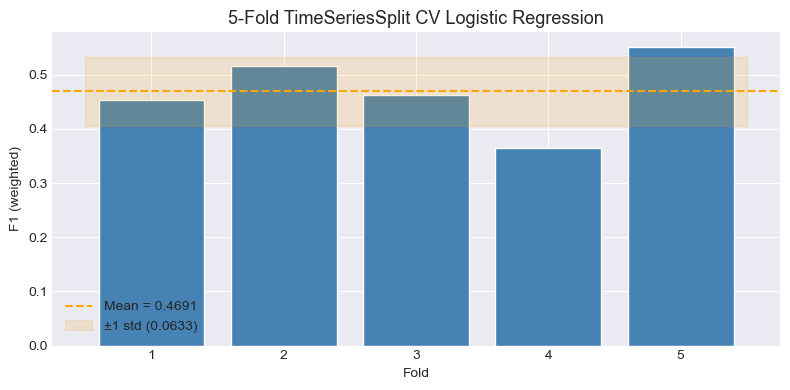

In [24]:
# Re-scale full dataset inside a Pipeline so each CV fold is scaled independently
# (prevents test-fold statistics leaking into the scaler's fit)
X_all = df[FEATURE_COLUMNS]
y_all = df['target']

# Map best model name to its model object for cloning
_model_objs = {
    'Baseline (Majority Class)': dummy,
    'Logistic Regression':       lr_model,
    'Random Forest':             rf_model,
    'XGBoost':                   xgb_model,
}
best_model_obj = _model_objs[BEST_MODEL_NAME]

# Pipeline ensures the scaler is re-fit on each fold's training portion only
cv_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('model',  clone(best_model_obj)),
])

tscv = TimeSeriesSplit(n_splits=5)
cv_scores = cross_val_score(
    cv_pipeline,
    X_all,
    y_all,
    cv=tscv,
    scoring='f1_weighted',
)

logger.info(
    'TimeSeriesSplit CV mean F1: %.4f | std: %.4f',
    cv_scores.mean(), cv_scores.std(),
)
print(f'F1 per fold : {[round(s, 4) for s in cv_scores]}')
print(f'Mean F1     : {cv_scores.mean():.4f}')
print(f'Std dev     : {cv_scores.std():.4f}')

# Fold score bar chart
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    range(1, len(cv_scores) + 1), cv_scores,
    color='steelblue', edgecolor='white',
)
ax.axhline(
    cv_scores.mean(), color='orange', linestyle='--', linewidth=1.5,
    label=f'Mean = {cv_scores.mean():.4f}',
)
ax.fill_between(
    [0.5, len(cv_scores) + 0.5],
    cv_scores.mean() - cv_scores.std(),
    cv_scores.mean() + cv_scores.std(),
    alpha=0.15, color='orange', label=f'±1 std ({cv_scores.std():.4f})',
)
ax.set_xlabel('Fold')
ax.set_ylabel('F1 (weighted)')
ax.set_title(f'5-Fold TimeSeriesSplit CV {BEST_MODEL_NAME}')
ax.set_xticks(range(1, len(cv_scores) + 1))
ax.legend()
plt.tight_layout()
plt.show()

### Validation Interpretation

A **low standard deviation** across folds indicates stable generalisation the model does not depend on a lucky split. A **high standard deviation** reveals that performance varies significantly across time periods, which may indicate sensitivity to market regimes.

If the mean CV F1 is close to the held-out test F1 from Section 8, the single-split evaluation was representative. If the test F1 is substantially higher than CV mean F1, the test period was unusually easy for this model and production performance should be expected to match the CV mean rather than the single-split result.

---
## Section 11 Business Value Interpretation

### What the model predicts and for whom

This model predicts the **binary next-day direction** of MSFT's closing price (UP or DOWN, excluding days with moves smaller than ±0.5 %). It is designed for **retail / non-professional investors** who use the MSFT Forecaster dashboard as a decision-support tool not as an automated trading system. The output is one signal among many; users are expected to apply their own judgement and risk tolerance.

### What the metrics mean in practice

A weighted F1 score above ~0.55 indicates the model extracts genuine directional signal from the features. In practical terms:
- If F1 ≈ 0.55–0.60: the model is correct on ~6 in 10 directional moves useful as a supporting signal but not for high-stakes leveraged positions.
- If F1 > 0.65: the model captures meaningful momentum or macro signals and can justify more weight in a decision framework.
- Accuracy above 55 % on a near-50/50 problem is already above the efficient-market null hypothesis for short-horizon equity prediction.

### Limitations

| Limitation | Impact |
|---|---|
| Model is not retrained automatically | Performance degrades as market regimes shift; manual retraining required |
| MSFT only | Does not generalise to other stocks or sectors without retraining |
| No real-time data | Predictions are based on end-of-day data; intraday signals are ignored |
| Binary prediction only | Does not estimate the *magnitude* of the move a predicted UP could be +0.6 % or +8 % |
| Neutral days excluded | The model is silent on ~20–30 % of trading days; a dashboard must communicate this clearly |
| Historical features only | Earnings dates, analyst upgrades, macro announcements are not included |

### Dashboard integration

The best model (and scaler) are saved to `models/`. The Streamlit dashboard can:
1. Load `scaler.pkl` and the best model `.pkl` at startup with `joblib.load()`.
2. Accept today's OHLCV and macro inputs (or fetch them automatically via the data pipeline).
3. Construct the feature vector using the same `FEATURE_COLUMNS` list.
4. Call `model.predict_proba()` for a confidence score, not just `model.predict()` for a binary label.
5. Display the predicted direction, confidence level, and a disclaimer that this is not financial advice.
6. Show the error analysis chart from Section 9 so users understand the model's historical failure modes before acting on its output.